In [245]:
import torch
import torch.nn.functional as F
import random
from torchjpeg import dct
 
def dct_transform(x, chs_remove=None, chs_pad=False):
    assert x.shape[1] == 3

    # x = x * 0.5 + 0.5
    size = random.choice([16]); stride = size; pad = 0; dilation = 1; ratio = size

    # up-sample
    x = F.interpolate(x, scale_factor=ratio, mode='bilinear', align_corners=True)

    # convert to the YCbCr color domain, required by DCT
    x = x * 255
    x = dct.to_ycbcr(x)
    x = x - 128

    # perform block discrete cosine transform (BDCT)
    b, c, h, w = x.shape
    n_block = h // stride
    x = x.view(b * c, 1, h, w)
    x = F.unfold(x, kernel_size=(size, size), dilation=dilation, padding=pad, stride=(stride, stride))
    x = x.transpose(1, 2)
    x = x.view(b, c, -1, size, size)
    x_freq = dct.block_dct(x)
    x_freq = x_freq.view(b, c, n_block, n_block, size * size).permute(0, 1, 4, 2, 3)
    chs_remove = list(range(35)) 
    channels = list(set([i for i in range(x_freq.shape[2])]) - set(chs_remove))
    print(len(channels))
    # channels = random.sample(channels, random.randint(int(len(channels) * 0.9), len(channels)))
    print(channels)
    print(len(channels))
    x_freq = x_freq[:, :, channels, :, :] 

    x_freq = x_freq.reshape(b, -1, n_block, n_block)
    x_freq = x_freq.reshape(b, 3, -1, n_block, n_block)
    x_freq = x_freq.mean(dim=2)
    # x_freq = x_freq.mean(dim=1, keepdim=True).repeat(1,3,1,1)
    x_freq = x_freq
    return x_freq


In [246]:
import sys
sys.path.append("../../methods/fracface")
import data2npy

In [247]:
# with open("../log/insight_student_embeddings_val_epoch_final.pkl", "rb") as f:
#     embedding_teacher_dict = torch.load(f)

In [248]:
# embedding_teacher_dict["templates"][0][0]

In [249]:
import os
import numpy as np
import torch
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
seed_everything()

In [255]:
import kornia

def fix_stripes(x):
    return kornia.enhance.equalize_clahe(x, clip_limit=2.0, grid_size=(4, 4))

221
[35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 

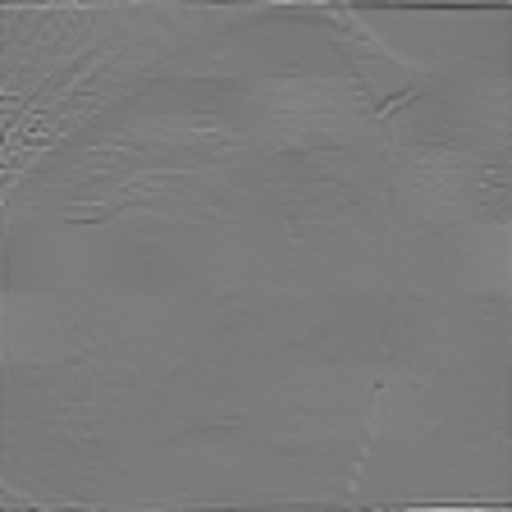

In [ ]:
import pylab 
from PIL import Image 
import numpy as np
import cv2

# img = cv2.imread("/path/to/lfw/lfw_112x112/3.bmp")
img = cv2.imread("raw_debug.png")
# frac_template = data2npy.preprocess_and_return(Image.fromarray(np.random.randn(*img.shape).astype(np.uint8)), 1)[0]
# seed_everything()
# frac_template = frac_template.reshape(3, -1, 112, 112).mean(1)[None,:]
# frac_template = (frac_template - frac_template.min()) / (frac_template.max() - frac_template.min())
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = torch.tensor(img) 
img = (img - img.min()) / (img.max() - img.min()) 
conv_img = dct_transform(img.unsqueeze(0).permute(0,3,1,2).float())
print(conv_img.shape)
img = conv_img[0].permute(1,2,0)

# img = img.mean(-1) 
# img = (img - img.mean(dim=1, keepdim=True))/(img.std(dim=1, keepdim=True) + 1e-6)
img = (img - img.min()) / (img.max() - img.min()).numpy()
img = img.mean(-1, keepdims=True).repeat(1,1,3)
Image.fromarray((img.cpu().numpy() * 255).astype("uint8")).resize((512, 512))

# pylab.subplot(1,2,1) 
# pylab.imshow(frac_template[0].permute(1,2,0).numpy().mean(-1), cmap='gray')
# pylab.title("FracFace Template")
# pylab.axis('off') 
# pylab.subplot(1,2,2) 
# print(img.shape)
# pylab.imshow(img, cmap='gray', vmin=0, vmax=1)
# pylab.title("Proxy Transformation")
# pylab.axis('off') 

In [251]:
img.shape

torch.Size([112, 112, 3])

221
[35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 

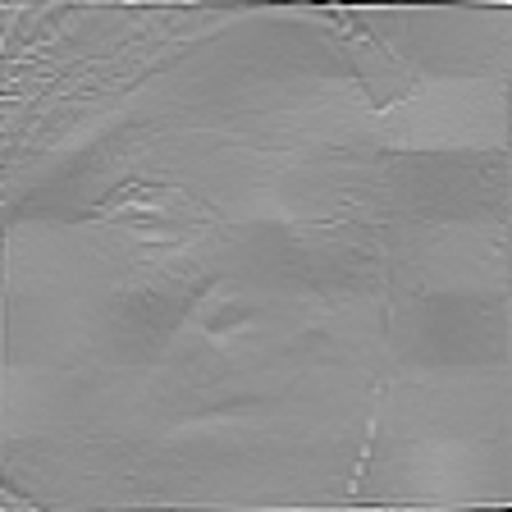

In [ ]:
import cv2
from PIL import Image
import torch

img = cv2.imread("raw_debug.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = torch.tensor(img).float() 
# img = img.mean(-1, keepdim=True).repeat(1,1,3)
img = (img - img.min()) / (img.max() - img.min())
img = img#.contiguous()
conv_img = dct_transform(img.unsqueeze(0).permute(0,3,1,2))
print(conv_img.shape)
img = conv_img[0].permute(1,2,0)

img = (img - img.min()) / (img.max() - img.min()).numpy() 
img = img.mean(-1, keepdims=True).repeat(1,1,3)

Image.fromarray((img.cpu().numpy() * 255).astype("uint8")).resize((512, 512))

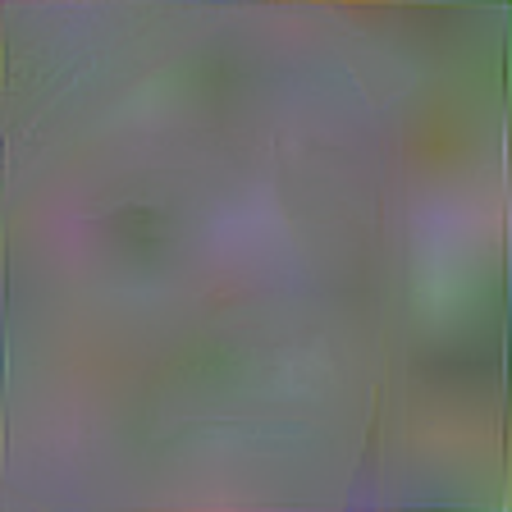

In [253]:
Image.open("raw_debug.png").resize((512, 512))

In [254]:
# import pylab 
# from PIL import Image
# import cv2
# import numpy as np
# img = cv2.imread("/path/to/lfw/lfw_112x112/0.bmp")
# frac_template = data2npy.preprocess_and_return(Image.fromarray(img), 1)[0]
# padding = torch.zeros((3 * 64 - 81,112,112))
# frac_template = torch.cat([frac_template, padding], dim=0)
# # inv = idct_transform(frac_template[None]).numpy()[0].transpose(1,2,0)
# # inv = (inv - inv.min()) / (inv.max() - inv.min()) 
# pylab.imshow(np.abs(frac_template.permute(1,2,0).numpy()).max(-1), cmap='gray') 